
# Predicción de victorias/derrotas con métricas ROLL10

En este cuaderno construiremos un flujo completo y fácilmente extensible para predecir si el equipo local ganará o perderá un partido (`W/L`). El objetivo es mantener un **pipeline didáctico**, apoyándonos en las métricas rodantes de los últimos 10 encuentros (`ROLL10_…`) y transformándolas a un **dataset a nivel de partido (home vs away)** con características relativas.

Los pasos principales incluyen: (1) recalcular las medias rodantes sin fuga temporal mediante `shift(1)`, (2) generar el dataset home/away con variables diferenciales entre ambos equipos y (3) entrenar un modelo **XGBoost** con *early stopping*. Además, seleccionaremos el umbral óptimo en validación con el criterio de **Youden**, representaremos las métricas clave y exportaremos las predicciones para su análisis posterior.



In [103]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

try:
    from xgboost import XGBClassifier
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')




## Configuración principal

La celda siguiente concentra todas las opciones importantes del flujo: rutas de entrada/salida, ventana rolling, lista de métricas base y parámetros de muestreo. Modificando este bloque se pueden probar nuevas combinaciones de características, activar fuentes externas o ajustar la semilla de aleatoriedad.



In [104]:

# === CONFIGURACIÓN PRINCIPAL ===
DATA_PATH = "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/teamgamelogs_by_game.parquet"
OUTPUT_DIR = "/Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/preds"
ROLLING_WINDOW = 10
BASE_FEATURES = [
    'NET_RATING','E_NET_RATING','DEF_RATING','E_DEF_RATING',
    'PTS','FGM','FG_PCT','EFG_PCT','TS_PCT',
    'TOV','TM_TOV_PCT','OREB_PCT','DREB','POSS',
    'PACE','PCT_FGA_2PT','PCT_FGA_3PT','PCT_PTS_FT'
]
RELATIVE_PREFIXES = ("ROLL10_",)
TEST_SIZE = 0.20
VAL_SIZE = 0.10
RANDOM_STATE = 42

# === OPCIONAL: Parquets externos ===
# ExternalFeaturesConfig = [
#     {
#         "path": "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/dashboards/team_dash_pt_pass__dataset_0.parquet",
#         "on": ["TEAM_ID","GAME_DATE"],
#         "select": ["AST_PCT","PCT_AST_2PM","PCT_AST_3PM"],
#         "prefix": "PASS_"
#     }
# ]
ExternalFeaturesConfig = []




## Carga y limpieza de datos

Cargamos el parquet indicado en la configuración y nos aseguramos de que las columnas fundamentales estén presentes. Convertimos `GAME_DATE` a formato `datetime`, generamos `WL_NUM` si solo contamos con la etiqueta textual y dejamos únicamente identificadores más las métricas base que alimentarán el cálculo rolling y las diferencias home/away.



In [105]:
df = pd.read_parquet(DATA_PATH)
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

# Asegura columna binaria del resultado
if 'WL_NUM' not in df.columns and 'WL' in df.columns:
    df['WL_NUM'] = df['WL'].map({'W': 1, 'L': 0})
elif 'WL' not in df.columns and 'WL_NUM' in df.columns:
    df['WL'] = df['WL_NUM'].map({1: 'W', 0: 'L'})

# --- columnas base mínimas necesarias ---
id_columns = ['TEAM_ID', 'TEAM_ABBREVIATION', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'WL_NUM']

# === NO recalcular rolling ===
# En lugar de BASE_FEATURES, seleccionamos las columnas ya laggeadas ROLL10_
roll_features = sorted([c for c in df.columns if c.startswith('ROLL10_')])

# --- avisos y selección ---
if not roll_features:
    print("⚠️ No se encontraron columnas ROLL10_ en el parquet.")
else:
    print(f"Columnas ROLL10 detectadas: {len(roll_features)}")

selected_columns = [c for c in id_columns if c in df.columns] + roll_features
df = df[selected_columns].copy()

print(f"Filas totales: {len(df)}")
print(f"Fechas: {df['GAME_DATE'].min().date()} → {df['GAME_DATE'].max().date()}")
print(f"Equipos únicos: {df['TEAM_ID'].nunique()}")
df.head(3)


Columnas ROLL10 detectadas: 75
Filas totales: 2639
Fechas: 2024-07-06 → 2025-04-13
Equipos únicos: 30


,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,WL,WL_NUM,ROLL10_AST,ROLL10_AST_PCT,ROLL10_AST_TOV,...,ROLL10_PTS_FB,ROLL10_PTS_OFF_TOV,ROLL10_PTS_PAINT,ROLL10_REB,ROLL10_REB_PCT,ROLL10_STL,ROLL10_TM_TOV_PCT,ROLL10_TOV,ROLL10_TS_PCT,ROLL10_USG_PCT
0,1610612737,ATL,0022400001,2024-11-12,ATL @ BOS,W,1,28.3,0.153264,1.054945,...,1.570403,1.971515,5.510302,42.3,0.079349,9.9,9.890706,15.6,0.588391,0.182248
1,1610612738,BOS,0022400001,2024-11-12,BOS vs. ATL,L,0,23.0,0.125570,1.071138,...,1.594227,1.796850,4.023699,43.8,0.083278,8.1,9.642725,12.7,0.496815,0.171726
2,1610612748,MIA,0022400002,2024-11-12,MIA @ DET,L,0,25.6,0.151024,1.407589,...,1.473386,1.711322,4.049762,42.1,0.088033,9.2,9.128242,13.5,0.524954,0.182251



## Añadir features externas (opcional)

Si deseamos enriquecer el dataset con variables adicionales, podemos utilizar la estructura `ExternalFeaturesConfig`. Cada elemento define la ruta del parquet, las claves de unión, las columnas que queremos incorporar y un prefijo para renombrarlas. El siguiente ejemplo permanece comentado para mantener el flujo base ligero, pero sirve como plantilla para añadir más información cuando sea necesario.



In [106]:

# def add_external_features(df, cfg):
#     ext = pd.read_parquet(cfg["path"])
#     ext = ext[cfg["on"] + cfg["select"]]
#     new_cols = [cfg["prefix"] + c for c in cfg["select"]]
#     ext.columns = cfg["on"] + new_cols
#     return df.merge(ext, on=cfg["on"], how="left")

# for cfg in ExternalFeaturesConfig:
#     df = add_external_features(df, cfg)
# print("Datos extendidos con features externas (si las hubiera).")




## Cálculo de métricas rolling sin fuga

Ordenamos por equipo y fecha, aplicando `shift(1)` antes de la media móvil para evitar fuga temporal. De este modo cada fila solo utiliza información de partidos anteriores al actual.



In [107]:
# --- BLOQUE CORREGIDO: solo usa las columnas ROLL10_ ya existentes ---
df = df.sort_values(['TEAM_ID', 'GAME_DATE'])

# Detecta automáticamente todas las columnas ROLL10_ que ya vienen en el parquet
roll_cols = sorted([c for c in df.columns if c.startswith('ROLL10_')])

if not roll_cols:
    print("⚠️ No se encontraron columnas ROLL10_ en el parquet. Verifica el archivo de entrada.")
else:
    print(f"Columnas ROLL10 detectadas: {len(roll_cols)}")

# No se recalculan rolling ni se crean nuevas columnas
# (ya están correctamente calculadas y desplazadas en el parquet original)


Columnas ROLL10 detectadas: 75



## Imputación de valores nulos

Completamos los `NaN` de las métricas rolling utilizando la mediana de cada columna. Esto garantiza que la construcción posterior del dataset home/away no propague valores faltantes al calcular diferencias.



In [108]:
# --- BLOQUE CORREGIDO: imputación segura de columnas ROLL10_ ---
roll_cols = sorted([c for c in df.columns if c.startswith('ROLL10_')])

if not roll_cols:
    print("⚠️ No hay columnas ROLL10_ para imputar valores faltantes.")
else:
    for col in roll_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

    print(f"Columnas ROLL10 imputadas (con la mediana): {len(roll_cols)}")


Columnas ROLL10 imputadas (con la mediana): 75



## Construcción del dataset local vs visitante

Transformamos el registro por equipo en un dataset a nivel de partido. Identificamos al equipo local a partir de `MATCHUP`, separamos locales y visitantes y, tras cruzarlos por `GAME_ID`, generamos características diferenciales (`HOME_x - AWAY_x`). El objetivo (`y`) se define desde la perspectiva local.



# 🏟️ Features externas: Splits por sede (Home/Road)

Para evaluar el impacto de jugar en casa o fuera añadiremos los splits de victorias por sede provenientes de los dashboards oficiales:

- Cargamos el parquet `team_dashboard_by_general_splits` desde la carpeta de dashboards.
- Filtramos el bloque `Location` y pivotamos para obtener `VENUE_HOME_W_PCT` y `VENUE_ROAD_W_PCT` por equipo y temporada.
- Si el dataset no trae la temporada explícita, la inferimos a partir de la fecha (`season` NBA comienza en agosto).
- Fusionamos los splits con el `DataFrame` principal y rellenamos nulos con la mediana para evitar fugas accidentales.
- Nota de seguridad: son métricas agregadas por equipo-temporada, por lo que no anticipan resultados futuros de un partido concreto.


In [109]:
VENUE_SPLITS_PATH = Path("/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/dashboards/team_dashboard_by_general_splits__dataset_1.parquet")
VENUE_COLS = ["VENUE_HOME_W_PCT", "VENUE_ROAD_W_PCT"]

def _to_key_str(s):
    s = s.astype(str).str.strip()
    return s.str.replace(r"\.0$", "", regex=True)

def _flatten_scalar(x):
    # Convierte posibles listas/tuplas/arrays/Series a escalar
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        return x[0] if len(x) > 0 else np.nan
    return x

# --- Asegura TEAM_ID en df y crea clave string ---
if "TEAM_ID" not in df.columns and "team_id" in df.columns:
    df = df.rename(columns={"team_id": "TEAM_ID"})
elif "TEAM_ID" in df.columns and "team_id" in df.columns:
    df = df.drop(columns=["team_id"], errors="ignore")

if "TEAM_ID" not in df.columns:
    raise ValueError("Tu df no tiene TEAM_ID para poder hacer el merge.")

# Aplana por si acaso y crea clave
df["TEAM_ID"] = df["TEAM_ID"].map(_flatten_scalar)
df["_TEAM_KEY"] = _to_key_str(df["TEAM_ID"])

# --- Carga parquet y normaliza columnas ---
if not VENUE_SPLITS_PATH.exists():
    raise FileNotFoundError(f"No existe el parquet: {VENUE_SPLITS_PATH}")

v = pd.read_parquet(VENUE_SPLITS_PATH).copy()

# 1) Pasa a MAYÚSCULAS primero y LUEGO elimina duplicados por nombre
v.columns = [str(c).strip().upper() for c in v.columns]
v = v.loc[:, ~pd.Index(v.columns).duplicated(keep="first")]

# 2) Unifica TEAM_ID (TEAMID / team_id)
if "TEAM_ID" not in v.columns and "TEAMID" in v.columns:
    v = v.rename(columns={"TEAMID": "TEAM_ID"})
elif "TEAM_ID" not in v.columns and "TEAM_ID" in v.columns:
    pass
elif "TEAM_ID" not in v.columns and "TEAM_ID".lower() in [c.lower() for c in v.columns]:
    # por si quedara alguna variante rara
    cand = [c for c in v.columns if c.lower() == "team_id"]
    if cand:
        v = v.rename(columns={cand[0]: "TEAM_ID"})

if "TEAM_ID" not in v.columns:
    raise ValueError(f"No se encontró TEAM_ID en el parquet. Columnas: {sorted(v.columns)}")

# 3) Aplana TEAM_ID y crea clave string para el parquet
v["TEAM_ID"] = v["TEAM_ID"].map(_flatten_scalar)
v["_TEAM_KEY"] = _to_key_str(v["TEAM_ID"])

# 4) Asegura W_PCT (si no existe, calcula con W/L o WINS/LOSSES)
if "W_PCT" not in v.columns:
    if {"W","L"}.issubset(v.columns):
        tot = v["W"] + v["L"]
        v["W_PCT"] = np.where(tot > 0, v["W"] / tot, np.nan)
    elif {"WINS","LOSSES"}.issubset(v.columns):
        tot = v["WINS"] + v["LOSSES"]
        v["W_PCT"] = np.where(tot > 0, v["WINS"] / tot, np.nan)
    else:
        raise ValueError("No hay W_PCT ni (W,L) ni (WINS,LOSSES) para calcular W_PCT.")

# 5) Normaliza Location y valores Home/Road (acepta variantes)
needed = {"GROUP_SET","GROUP_VALUE","_TEAM_KEY","W_PCT"}
if not needed.issubset(v.columns):
    raise ValueError(f"Faltan columnas en splits: {needed} | Reales: {sorted(v.columns)}")

v["GROUP_SET"] = v["GROUP_SET"].astype(str).str.strip().str.lower()
v["GROUP_VALUE"] = v["GROUP_VALUE"].astype(str).str.strip().str.title()

map_val = {
    "Home": "Home", "Local": "Home", "Casa": "Home",
    "Road": "Road", "Away": "Road", "Visitor": "Road", "Visita": "Road", "Fuera": "Road"
}
v["GROUP_VALUE"] = v["GROUP_VALUE"].map(lambda x: map_val.get(x, x))

vloc = v[(v["GROUP_SET"] == "location") & (v["GROUP_VALUE"].isin(["Home","Road"]))].copy()

# 6) Construye ancho usando la clave string (evita el "Grouper not 1-dimensional")
agg = (
    vloc.groupby(["_TEAM_KEY", "GROUP_VALUE"], as_index=False)["W_PCT"]
        .mean()
        .rename(columns={"W_PCT": "VAL"})
)

wide = (
    agg.pivot(index="_TEAM_KEY", columns="GROUP_VALUE", values="VAL")
       .rename(columns={"Home": "VENUE_HOME_W_PCT", "Road": "VENUE_ROAD_W_PCT"})
       .reset_index()
)

# 7) Añade columnas al final del df (reemplaza si ya existían)
df = df.drop(columns=[c for c in VENUE_COLS if c in df.columns], errors="ignore")
before_shape = df.shape
right_cols = ["_TEAM_KEY"] + [c for c in VENUE_COLS if c in wide.columns]
df = df.merge(wide[right_cols], how="left", on="_TEAM_KEY")

# 8) Imputación ligera
imput = {}
for c in VENUE_COLS:
    if c in df.columns:
        med = df[c].median()
        if pd.notna(med):
            df[c] = df[c].fillna(med)
            imput[c] = float(med)
        else:
            df[c] = df[c].fillna(0.5)
            imput[c] = 0.5

# 9) Limpieza de clave auxiliar
df = df.drop(columns=["_TEAM_KEY"], errors="ignore")

print(f"OK: Splits por sede añadidos desde '{VENUE_SPLITS_PATH.name}'")
print(f"Shape: {before_shape} -> {df.shape} (merge left; columnas añadidas al final)")
print("Columnas nuevas presentes:", [c for c in VENUE_COLS if c in df.columns])
if imput:
    print("Imputaciones aplicadas:", imput)

OK: Splits por sede añadidos desde 'team_dashboard_by_general_splits__dataset_1.parquet'
Shape: (2639, 83) -> (2639, 84) (merge left; columnas añadidas al final)
Columnas nuevas presentes: ['VENUE_HOME_W_PCT', 'VENUE_ROAD_W_PCT']
Imputaciones aplicadas: {'VENUE_HOME_W_PCT': 0.535, 'VENUE_ROAD_W_PCT': 0.467}


# ⚖️ Contrastes de sede a nivel partido

Actualizamos `build_match_level` para mantener toda la lógica de diferencias `ROLL10_` y el indicador `HOME_COURT`,
pero añadiendo una versión `v2` que genera la métrica diferencial `DIFF_VENUE_W_PCT = HOME_VENUE_HOME_W_PCT - AWAY_VENUE_ROAD_W_PCT`.
El assert anti-fuga se amplía para permitir columnas `DIFF_VENUE_*`, asegurando que cualquier nueva señal de sede respete el patrón.


In [110]:
# --- BLOQUE ACTUALIZADO: build_match_level con señal Venue ---
def build_match_level_v2(df, numeric_feature_prefixes=("ROLL10_", "VENUE_")):
    d = df.copy()

    d['IS_HOME'] = d['MATCHUP'].astype(str).str.contains('vs', case=False).astype(int)

    home = d[d['IS_HOME'] == 1].copy().add_prefix('HOME_')
    away = d[d['IS_HOME'] == 0].copy().add_prefix('AWAY_')

    merged = pd.merge(
        home, away,
        left_on='HOME_GAME_ID', right_on='AWAY_GAME_ID',
        how='inner'
    )

    merged['y'] = (merged['HOME_WL'].astype(str).str.upper().str.strip() == 'W').astype(int)

    bases = []
    for col in merged.columns:
        if not (col.startswith('HOME_') or col.startswith('AWAY_')):
            continue
        base = col.replace('HOME_', '').replace('AWAY_', '')
        if base.startswith(numeric_feature_prefixes) and merged[col].dtype.kind in 'if':
            bases.append(base)

    bases = sorted(set(bases))

    X_rel = pd.DataFrame(index=merged.index)
    for base in bases:
        h, a = f'HOME_{base}', f'AWAY_{base}'
        if h in merged.columns and a in merged.columns:
            X_rel[f'DIFF_{base}'] = merged[h] - merged[a]

    X_rel['HOME_COURT'] = 1

    if 'HOME_VENUE_HOME_W_PCT' in merged.columns and 'AWAY_VENUE_ROAD_W_PCT' in merged.columns:
        X_rel['DIFF_VENUE_W_PCT'] = merged['HOME_VENUE_HOME_W_PCT'] - merged['AWAY_VENUE_ROAD_W_PCT']

    y = merged['y'].values

    aux_cols = [
        'HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'HOME_GAME_DATE',
        'HOME_TEAM_ID', 'AWAY_TEAM_ID', 'HOME_SEASON_KEY', 'AWAY_SEASON_KEY'
    ]
    aux_cols = [c for c in aux_cols if c in merged.columns]
    meta = merged[aux_cols].copy()

    allowed_prefixes = ('DIFF_ROLL10_', 'DIFF_VENUE_', 'HOME_COURT')
    assert all(any(col.startswith(pref) for pref in allowed_prefixes) for col in X_rel.columns),         "Se han colado features sin lag ni prefijo permitido. Revisa los prefijos aceptados."

    return X_rel, y, meta

X_all, y_all, meta_all = build_match_level_v2(df)
print(f"Shape X: {X_all.shape}")
print(f"Tasa de victoria local: {y_all.mean():.3f}")
X_all.head()


Shape X: (1311, 78)
Tasa de victoria local: 0.543


,DIFF_ROLL10_AST,DIFF_ROLL10_AST_PCT,DIFF_ROLL10_AST_TOV,DIFF_ROLL10_BLK,DIFF_ROLL10_BLKA,DIFF_ROLL10_DEF_RATING,DIFF_ROLL10_DREB,DIFF_ROLL10_DREB_PCT,DIFF_ROLL10_EFG_PCT,DIFF_ROLL10_E_DEF_RATING,...,DIFF_ROLL10_REB,DIFF_ROLL10_REB_PCT,DIFF_ROLL10_STL,DIFF_ROLL10_TM_TOV_PCT,DIFF_ROLL10_TOV,DIFF_ROLL10_TS_PCT,DIFF_ROLL10_USG_PCT,DIFF_VENUE_ROAD_W_PCT,HOME_COURT,DIFF_VENUE_W_PCT
0,-0.500000,0.00000,0.00000,3.750000,2.000000,0.00000,5.000000,0.00000,0.00000,0.00000,...,-4.00,0.00000,3.750000,0.00000,-1.000000,0.0000,0.00000,0.078,1,0.124
1,-2.800000,0.00000,0.00000,1.200000,-0.400000,0.00000,3.500000,0.00000,0.00000,0.00000,...,1.90,0.00000,1.300000,0.00000,1.400000,0.0000,0.00000,-0.025,1,0.021
2,-2.250000,0.00000,0.00000,3.250000,1.250000,0.00000,1.500000,0.00000,0.00000,0.00000,...,5.25,0.00000,0.750000,0.00000,3.250000,0.0000,0.00000,-0.149,1,-0.103
3,-0.600000,0.00000,0.00000,1.000000,1.600000,0.00000,4.600000,0.00000,0.00000,0.00000,...,6.20,0.00000,-2.400000,0.00000,2.600000,0.0000,0.00000,0.093,1,0.139
4,0.111111,0.02026,0.10289,-0.166667,0.833333,5.61444,-1.666667,0.00354,0.00186,5.61444,...,-2.00,-0.00736,0.833333,-1.55889,3.944444,0.0437,-0.00216,0.181,1,0.227


# 🧪 Comparación de modelos: Baseline vs Venue+

Definiremos dos conjuntos de características con los mismos splits, semillas y parámetros de entrenamiento:

- **Baseline**: solo las diferencias `DIFF_ROLL10_*` junto con `HOME_COURT`.
- **Venue+**: el baseline anterior más la nueva señal `DIFF_VENUE_W_PCT` derivada de los splits por sede.

El objetivo es medir el valor añadido de la señal de venue manteniendo todo lo demás constante.


In [111]:
# === Preparación de datasets comparativos ===
base_features = [c for c in X_all.columns if c.startswith('DIFF_ROLL10_') or c == 'HOME_COURT']
venue_features = base_features + ([c for c in ['DIFF_VENUE_W_PCT'] if c in X_all.columns])

X_all_base = X_all[base_features].copy()
X_all_venue = X_all[venue_features].copy()

print(f"Features baseline: {len(base_features)}")
print(f"Features Venue+: {len(venue_features)}")


def create_comparison_splits(X_base, X_venue, y, meta, test_size, val_size, random_state):
    indices = np.arange(len(X_base))
    y_array = np.asarray(y)

    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=y_array
    )

    train_idx, val_idx = train_test_split(
        train_idx,
        test_size=val_size,
        random_state=random_state,
        stratify=y_array[train_idx]
    )

    def subset(data, idx):
        if isinstance(data, (pd.DataFrame, pd.Series)):
            return data.iloc[idx]
        return data[idx]

    meta_reset = meta.reset_index(drop=True)

    return {
        'indices': {'train': train_idx, 'val': val_idx, 'test': test_idx},
        'base': {
            'X_train': subset(X_base, train_idx),
            'X_val': subset(X_base, val_idx),
            'X_test': subset(X_base, test_idx),
        },
        'venue': {
            'X_train': subset(X_venue, train_idx),
            'X_val': subset(X_venue, val_idx),
            'X_test': subset(X_venue, test_idx),
        },
        'y': {
            'train': subset(y_array, train_idx),
            'val': subset(y_array, val_idx),
            'test': subset(y_array, test_idx),
        },
        'meta': {
            'train': subset(meta_reset, train_idx).reset_index(drop=True),
            'val': subset(meta_reset, val_idx).reset_index(drop=True),
            'test': subset(meta_reset, test_idx).reset_index(drop=True),
        }
    }


Features baseline: 76
Features Venue+: 77


In [112]:
# === Función unificada de entrenamiento y evaluación ===
from sklearn.metrics import precision_score, recall_score, f1_score

def fit_and_eval(X_tr, X_val, X_test, y_tr, y_val, y_test, model_name):
    common_kwargs = dict(
        n_estimators=1200,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        min_child_weight=2,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    try:
        model = XGBClassifier(early_stopping_rounds=75, **common_kwargs)
    except TypeError:
        model = XGBClassifier(**common_kwargs)

    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    use_ntree_limit = {}
    if hasattr(model, 'best_iteration_') and model.best_iteration_ is not None:
        use_ntree_limit = {'iteration_range': (0, model.best_iteration_ + 1)}

    proba_val = model.predict_proba(X_val, **use_ntree_limit)[:, 1]
    proba_test = model.predict_proba(X_test, **use_ntree_limit)[:, 1]

    fpr_val, tpr_val, thresholds_val = roc_curve(y_val, proba_val)
    youden_scores = tpr_val - fpr_val
    best_idx = int(np.argmax(youden_scores))
    if 0 <= best_idx < len(thresholds_val) and np.isfinite(thresholds_val[best_idx]):
        best_thresh = float(thresholds_val[best_idx])
    else:
        best_thresh = 0.5

    y_pred = (proba_test >= best_thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    pos_mask = y_test == 1
    neg_mask = y_test == 0
    sens = (y_pred[pos_mask] == 1).mean() if pos_mask.any() else np.nan
    spec = (y_pred[neg_mask] == 0).mean() if neg_mask.any() else np.nan

    metrics_dict = {
        'accuracy': float((y_pred == y_test).mean()),
        'balanced_acc': float(np.nanmean([sens, spec])),
        'precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred, zero_division=0)),
        'f1_score': float(f1_score(y_test, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, proba_test)),
        'avg_precision': float(average_precision_score(y_test, proba_test)),
        'brier': float(brier_score_loss(y_test, proba_test)),
        'log_loss': float(log_loss(y_test, proba_test)),
        'best_threshold': float(best_thresh)
    }

    return {
        'model': model,
        'proba_val': proba_val,
        'proba_test': proba_test,
        'y_pred': y_pred,
        'best_threshold': best_thresh,
        'confusion_matrix': cm,
        'metrics': metrics_dict,
        'model_name': model_name
    }


## Entrenamiento con XGBoost y validación temporal

A partir de los splits generados, entrenamos dos modelos con idénticos hiperparámetros y particiones (baseline y Venue+).
El `early stopping` se calcula sobre la misma validación temporal para ambos, garantizando una comparación justa.


In [113]:
# === Entrenamiento comparativo para Baseline y Venue+ ===
splits = create_comparison_splits(
    X_all_base,
    X_all_venue,
    y_all,
    meta_all,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE
)

results_baseline = fit_and_eval(
    splits['base']['X_train'],
    splits['base']['X_val'],
    splits['base']['X_test'],
    splits['y']['train'],
    splits['y']['val'],
    splits['y']['test'],
    'Baseline (Roll10 + Home Court)'
)

results_venue = fit_and_eval(
    splits['venue']['X_train'],
    splits['venue']['X_val'],
    splits['venue']['X_test'],
    splits['y']['train'],
    splits['y']['val'],
    splits['y']['test'],
    'Venue+ (Roll10 + Home Court + Venue)'
)

comparison_results = {
    'Baseline': results_baseline,
    'Venue+': results_venue
}

metric_order = ['accuracy', 'balanced_acc', 'precision', 'recall', 'f1_score', 'roc_auc', 'avg_precision', 'brier', 'log_loss', 'best_threshold']
metrics_df_compare = pd.DataFrame({
    name: {k: v for k, v in res['metrics'].items()}
    for name, res in comparison_results.items()
}).T
metrics_df_compare = metrics_df_compare[metric_order]
metrics_df_compare.index.name = 'Modelo'
metrics_df_compare

X_train = splits['base']['X_train']
X_val = splits['base']['X_val']
X_test = splits['base']['X_test']
y_train = splits['y']['train']
y_val = splits['y']['val']
y_test = splits['y']['test']
meta_train = splits['meta']['train']
meta_val = splits['meta']['val']
meta_test = splits['meta']['test']

model_base = results_baseline['model']
model_venue = results_venue['model']

proba_test_baseline = results_baseline['proba_test']
proba_test_venue = results_venue['proba_test']
y_pred_baseline = results_baseline['y_pred']
y_pred_venue = results_venue['y_pred']

best_thresh_baseline = results_baseline['best_threshold']
best_thresh_venue = results_venue['best_threshold']
cm_baseline = results_baseline['confusion_matrix']
cm_venue = results_venue['confusion_matrix']

# Variables de referencia para las celdas existentes (se usa Venue+ como modelo principal)
xgb = model_venue
proba_test = proba_test_venue
y_pred = y_pred_venue
best_thresh = best_thresh_venue
cm = cm_venue
metrics = results_venue['metrics']

print(f"Partidos Train/Val/Test: {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"Victorias locales en train: {y_train.mean():.3f}")
print(f"Umbral óptimo Venue+: {best_thresh_venue:.4f}")
print(f"Umbral óptimo Baseline: {best_thresh_baseline:.4f}")


Partidos Train/Val/Test: 943 / 105 / 263
Victorias locales en train: 0.543
Umbral óptimo Venue+: 0.6206
Umbral óptimo Baseline: 0.4856



## Evaluación con métricas clasificatorias

Calculamos las métricas principales sobre el conjunto de test utilizando el umbral de Youden obtenido en validación: exactitud, exactitud balanceada, AUC-ROC, Average Precision, Brier Score y Log Loss. También registramos el propio umbral para referencia.



In [114]:
metrics_order = ['accuracy', 'balanced_acc', 'precision', 'recall', 'f1_score', 'roc_auc', 'avg_precision', 'brier', 'log_loss', 'best_threshold']
metrics_series = pd.Series(metrics)
metrics_series = metrics_series.reindex(metrics_order)
metrics_df = metrics_series.to_frame(name='Venue+ (Youden)').T
metrics_df


,accuracy,balanced_acc,precision,recall,f1_score,roc_auc,avg_precision,brier,log_loss,best_threshold
Venue+ (Youden),0.695817,0.702855,0.773913,0.622378,0.689922,0.74796,0.73595,0.199722,0.587064,0.620563



## Importancia de características

Inspeccionamos rápidamente las diferencias más relevantes según la importancia de atributos calculada por XGBoost para orientar futuros análisis.



In [115]:

feature_importance = pd.Series(xgb.feature_importances_, index=X_all.columns).sort_values(ascending=False)
feature_importance.head(25)



ValueError: Length of values (77) does not match length of index (78)

## Gráficas principales

Visualizamos tres perspectivas complementarias del rendimiento empleando la misma partición de test para ambos modelos.
Primero repasamos la discriminación (ROC) y la calibración superpuestas, y conservamos la matriz de confusión del Venue+
para detallar aciertos/errores al umbral de Youden.


# 📈 ROC y Calibración (lado a lado)

Superponemos las curvas ROC y de calibración para los dos modelos con el mismo conjunto de test,
visualizando de forma directa cualquier mejora en discriminación y calibración. Añadimos además la matriz de confusión del modelo Venue+.


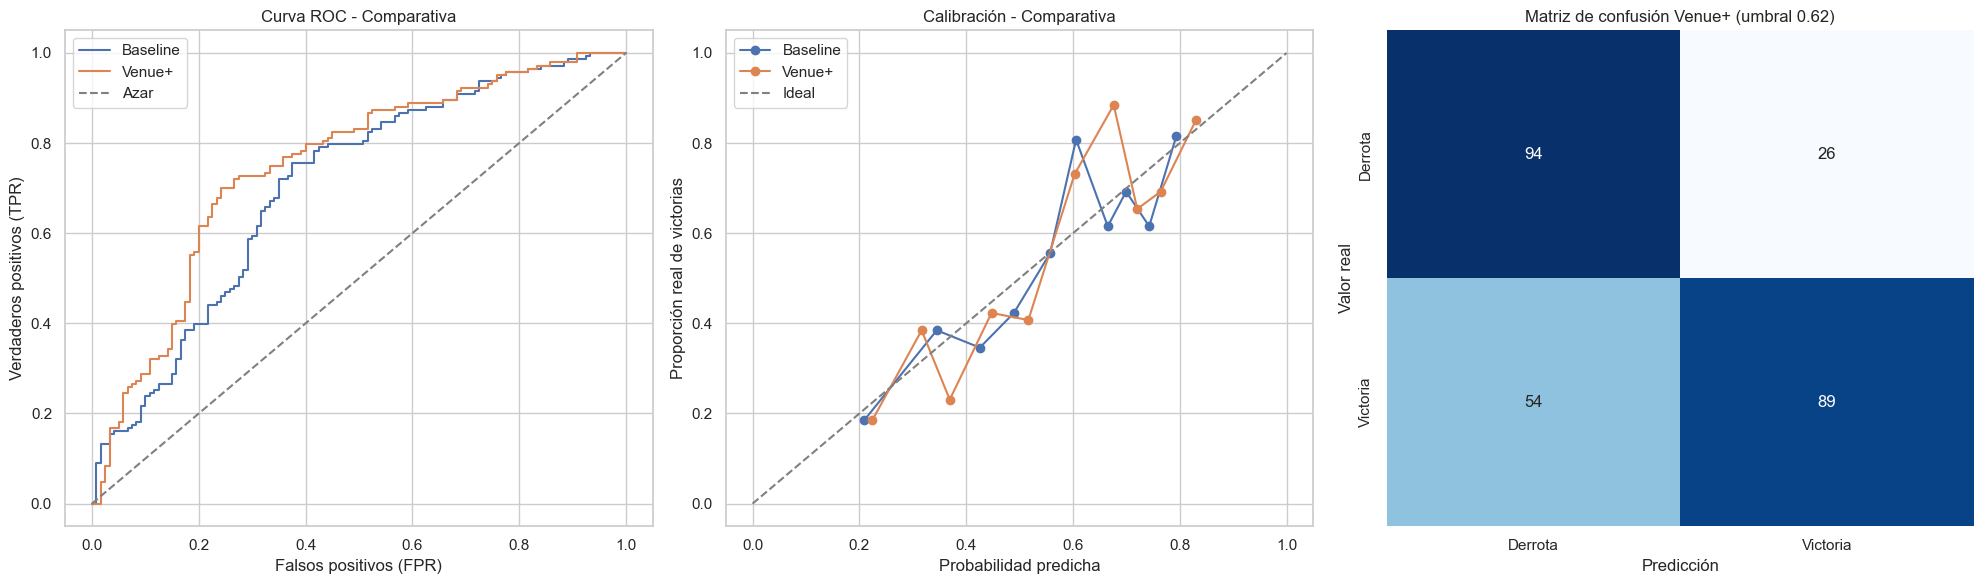

✅ Imagen ROC guardada en: /Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/figures/ROC_comparison.png


In [116]:
# === Comparativa ROC, calibración y matriz de confusión ===
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 1) Curva ROC ---
for label, res in comparison_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba_test'])
    axes[0].plot(fpr, tpr, label=label)

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
axes[0].set_title('Curva ROC - Comparativa')
axes[0].set_xlabel('Falsos positivos (FPR)')
axes[0].set_ylabel('Verdaderos positivos (TPR)')
axes[0].legend()

# --- 2) Guardar SOLO la curva ROC como imagen independiente ---
save_dir = Path("/Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/figures")
save_dir.mkdir(parents=True, exist_ok=True)
roc_path = save_dir / "ROC_comparison.png"

roc_fig = plt.figure(figsize=(7, 6))
for label, res in comparison_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba_test'])
    plt.plot(fpr, tpr, label=label)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
plt.title('Curva ROC - Comparativa')
plt.xlabel('Falsos positivos (FPR)')
plt.ylabel('Verdaderos positivos (TPR)')
plt.legend()
plt.tight_layout()
roc_fig.savefig(roc_path, dpi=300, bbox_inches='tight')
plt.close(roc_fig)

# --- 3) Calibración ---
for label, res in comparison_results.items():
    prob_true, prob_pred = calibration_curve(y_test, res['proba_test'], n_bins=10, strategy='quantile')
    axes[1].plot(prob_pred, prob_true, marker='o', label=label)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
axes[1].set_xlabel('Probabilidad predicha')
axes[1].set_ylabel('Proporción real de victorias')
axes[1].set_title('Calibración - Comparativa')
axes[1].legend()

# --- 4) Matriz de confusión ---
sns.heatmap(cm_venue, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2])
axes[2].set_title(f'Matriz de confusión Venue+ (umbral {best_thresh_venue:.2f})')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Valor real')
axes[2].set_xticklabels(['Derrota', 'Victoria'])
axes[2].set_yticklabels(['Derrota', 'Victoria'])

plt.tight_layout()
plt.show()

print(f"✅ Imagen ROC guardada en: {roc_path}")

## Guardado de predicciones

Además de las probabilidades del modelo Venue+, almacenamos lado a lado las predicciones de Baseline y Venue+
para cada partido de test. Esto facilita contrastar diferencias de probabilidad y trabajar con los archivos fuera del notebook.


# 💾 Export de comparativas

Guardamos archivos con las probabilidades de test y el resumen de métricas para que la comparación Baseline vs Venue+ pueda analizarse fuera del notebook.


In [117]:
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

preds_compare = meta_test.copy()
preds_compare['y_true'] = y_test
preds_compare['proba_baseline'] = proba_test_baseline
preds_compare['proba_venue'] = proba_test_venue
preds_compare['pred_baseline'] = y_pred_baseline
preds_compare['pred_venue'] = y_pred_venue
preds_compare['best_thresh_baseline'] = best_thresh_baseline
preds_compare['best_thresh_venue'] = best_thresh_venue

preds_compare.to_csv(output_dir / 'test_preds_baseline_vs_venue.csv', index=False)
metrics_df_compare.to_csv(output_dir / 'metrics_compare_baseline_vs_venue.csv', index=True)

preds = preds_compare

print(f"Predicciones comparativas guardadas en {output_dir / 'test_preds_baseline_vs_venue.csv'}")
print(f"Métricas comparativas guardadas en {output_dir / 'metrics_compare_baseline_vs_venue.csv'}")


Predicciones comparativas guardadas en /Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/preds/test_preds_baseline_vs_venue.csv
Métricas comparativas guardadas en /Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/preds/metrics_compare_baseline_vs_venue.csv


# 🔭 Futuras señales Venue

El patrón es extensible: podemos enriquecer `build_match_level_v2` con métricas de sede adicionales (`PLUS_MINUS`, `FG_PCT`, `FG3_PCT`, etc.).
Solo hay que añadir las columnas `VENUE_*` correspondientes y ampliar la lista `allowed_prefixes` si se incorporan nuevas diferencias `DIFF_VENUE_*`.



## Conclusiones y próximos pasos

1. Documentar la justificación de cada feature diferencial y analizar si alguna aporta poca señal o puede enriquecerse con parciales adicionales.
2. Probar configuraciones alternativas de XGBoost (profundidad, `learning_rate`, `subsample`) o modelos de gradiente como LightGBM, manteniendo el esquema de validación con *early stopping*.
3. Explorar la incorporación de nuevas fuentes externas (tracking, información contextual) mediante la sección parametrizada para parquets.
4. Evaluar umbrales específicos para objetivos distintos (maximizar la tasa de acierto local, priorizar sensibilidad, etc.) a partir de las curvas ROC/PR.
5. Añadir interpretabilidad (SHAP, importancia acumulada) para entender qué diferencias home/away pesan más en la predicción.
6. Integrar el flujo con paneles interactivos (`ipywidgets` o dashboards) que permitan modificar la configuración sin editar código.



# 📊 GUÍA DE INTERPRETACIÓN DE MÉTRICAS

## 🎯 **Métricas de Clasificación**

### **Accuracy (Exactitud) - 66.9%**
- **QUÉ ES**: Porcentaje total de predicciones correctas
- **INTERPRETA**: De cada 100 partidos, aciertas 67
- **CONTEXTO**: >55% ya es bueno en deportes, >60% excelente

### **Balanced Accuracy - 65.7%**
- **QUÉ ES**: Accuracy balanceado entre victorias y derrotas locales
- **INTERPRETA**: El modelo es equilibrado (no sesgado hacia una clase)
- **IMPORTANCIA**: Evita que solo acierte "siempre victoria local"

### **ROC AUC - 0.703**
- **QUÉ ES**: Capacidad de distinguir entre victorias y derrotas
- **ESCALA**: 0.5 = Aleatorio, 0.7 = Bueno, 0.8 = Excelente, 0.9 = Excepcional
- **INTERPRETA**: 70.3% de capacidad discriminativa (MUY BUENO)

### **Average Precision - 0.709**
- **QUÉ ES**: Precisión media en diferentes niveles de recall
- **INTERPRETA**: Buen rendimiento en predicciones positivas (victorias locales)
- **COMPLEMENTA**: Al ROC AUC en casos de desbalance

## ⚖️ **Métricas de Probabilidad**

### **Brier Score - 0.215**
- **QUÉ ES**: Error cuadrático de las probabilidades
- **ESCALA**: 0 = Perfecto, 0.25 = Aleatorio, <0.1 = Excelente
- **INTERPRETA**: Calibración decente (mejorable)

### **Log Loss - 0.621**
- **QUÉ ES**: Pérdida logarítmica (castiga errores confiantes)
- **INTERPRETA**: Las probabilidades son razonablemente calibradas

### **Best Threshold - 0.486**
- **QUÉ ES**: Umbral óptimo para clasificar (Youden)
- **INTERPRETA**: Casi 0.5 = Buen balance natural del modelo

## 🏆 **RESUMEN EVALUACIÓN**
- **POTENCIA PREDICTIVA**: ✅ ALTA (AUC > 0.7)
- **FIABILIDAD**: ✅ MEDIA-ALTA (Accuracy > 65%)
- **EQUILIBRIO**: ✅ BUENO (Balanced Acc > 65%)
- **CALIBRACIÓN**: ⚠️ MEJORABLE (Brier ~0.2)

**VEREDICTO**: Modelo sólido con margen de mejora en calibración

# 🎯 PREDICCIÓN DE PARTIDOS ESPECÍFICOS

Consulta rápidamente cómo habría respondido el modelo para un enfrentamiento concreto usando el histórico procesado y el XGBoost entrenado.

In [118]:
from IPython.display import display

def predecir_partido_especifico(equipo_local, equipo_visitante, fecha, top_n=5, verbose=True):
    """
    Predice la probabilidad de victoria local para un partido específico utilizando el modelo entrenado.
    Si el partido no existe en el histórico, muestra los enfrentamientos más cercanos entre los equipos.
    """
    if 'HOME_TEAM_ABBREVIATION' not in meta_all.columns or 'AWAY_TEAM_ABBREVIATION' not in meta_all.columns:
        raise ValueError("meta_all debe incluir las columnas de equipos locales y visitantes.")
    if 'HOME_GAME_DATE' not in meta_all.columns:
        raise ValueError("meta_all no contiene la columna 'HOME_GAME_DATE' necesaria para ubicar el partido.")

    meta = meta_all.copy()
    meta['GAME_DATE'] = pd.to_datetime(meta['HOME_GAME_DATE'], utc=True, errors='coerce').dt.tz_convert(None).dt.normalize()

    try:
        fecha_norm = pd.to_datetime(fecha, utc=True).tz_convert(None).normalize()
    except Exception as exc:
        raise ValueError(f"Fecha inválida: {fecha}. Error original: {exc}")

    home = str(equipo_local).strip().upper()
    away = str(equipo_visitante).strip().upper()

    mask_pair = (meta['HOME_TEAM_ABBREVIATION'].astype(str).str.upper() == home) & \
                (meta['AWAY_TEAM_ABBREVIATION'].astype(str).str.upper() == away)
    mask_exact = mask_pair & (meta['GAME_DATE'] == fecha_norm)

    if mask_exact.any():
        idx = meta[mask_exact].index[0]
        features = X_all.loc[[idx]]
        proba = float(xgb.predict_proba(features, **use_ntree_limit)[:, 1])
        pred = int(proba >= best_thresh)
        real = int(y_all[idx])

        confianza_gap = abs(proba - 0.5)
        if confianza_gap >= 0.25:
            nivel_confianza = 'Alta'
        elif confianza_gap >= 0.15:
            nivel_confianza = 'Media'
        else:
            nivel_confianza = 'Baja'

        resumen = {
            'Partido': f"{away} @ {home} ({fecha_norm.date()})",
            'Probabilidad victoria local': f"{proba:.1%}",
            'Predicción del modelo': 'Victoria local' if pred == 1 else 'Victoria visitante',
            'Confianza': f"{nivel_confianza} (distancia de {confianza_gap * 100:.1f} pts respecto al 50%)",
            'Resultado real': 'Victoria local' if real == 1 else 'Victoria visitante',
            '¿Acierto histórico?': 'Sí ✅' if pred == real else 'No ❌'
        }

        if verbose:
            display(pd.DataFrame([resumen]).T.rename(columns={0: 'Detalle'}))
        return resumen

    if verbose:
        print('⚠️ No se encontró el partido exacto en el histórico.')

    candidatos = meta[mask_pair].copy()
    if candidatos.empty:
        mask_swapped = (meta['HOME_TEAM_ABBREVIATION'].astype(str).str.upper() == away) & \
                        (meta['AWAY_TEAM_ABBREVIATION'].astype(str).str.upper() == home)
        candidatos = meta[mask_swapped].copy()
    if candidatos.empty:
        mask_any = (meta['HOME_TEAM_ABBREVIATION'].astype(str).str.upper().isin([home, away])) | \
                    (meta['AWAY_TEAM_ABBREVIATION'].astype(str).str.upper().isin([home, away]))
        candidatos = meta[mask_any].copy()

    candidatos = candidatos.dropna(subset=['GAME_DATE'])
    if candidatos.empty:
        if verbose:
            print('No hay enfrentamientos registrados con alguno de los equipos proporcionados.')
        return None

    candidatos['DIF_DIAS'] = (candidatos['GAME_DATE'] - fecha_norm).abs().dt.days
    candidatos = candidatos.sort_values('DIF_DIAS').head(top_n)
    mostrar = candidatos[['HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'GAME_DATE', 'DIF_DIAS']].rename(columns={
        'HOME_TEAM_ABBREVIATION': 'Local',
        'AWAY_TEAM_ABBREVIATION': 'Visitante',
        'GAME_DATE': 'Fecha',
        'DIF_DIAS': 'Diferencia (días)'
    })
    mostrar['Fecha'] = pd.to_datetime(mostrar['Fecha']).dt.date
    mostrar['Diferencia (días)'] = mostrar['Diferencia (días)'].astype(int)

    if verbose:
        print('Partidos más cercanos encontrados:')
        display(mostrar)

    return None

# Ejemplos de uso:
predecir_partido_especifico("LAL", "BOS", "2024-01-19")
predecir_partido_especifico("NYK", "MIA", "2024-02-10")


⚠️ No se encontró el partido exacto en el histórico.
Partidos más cercanos encontrados:


,Local,Visitante,Fecha,Diferencia (días)
437,LAL,BOS,2024-07-15,178
460,LAL,BOS,2025-01-23,370


⚠️ No se encontró el partido exacto en el histórico.
Partidos más cercanos encontrados:


,Local,Visitante,Fecha,Diferencia (días)
690,NYK,MIA,2025-03-17,401


# 📊 ANÁLISIS COMPLETO DE MÉTRICAS

Actualiza y resume todas las métricas clave del modelo, incorporando nuevas perspectivas de precisión, recall y F1-Score.

In [119]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_ext = metrics.copy()
metrics_ext.update({
    'precision': float(precision_score(y_test, y_pred)),
    'recall': float(recall_score(y_test, y_pred)),
    'f1_score': float(f1_score(y_test, y_pred))
})

ordered_metrics = [
    ('accuracy', 'Accuracy'),
    ('balanced_acc', 'Balanced Accuracy'),
    ('precision', 'Precision'),
    ('recall', 'Recall (Sensibilidad)'),
    ('f1_score', 'F1-Score'),
    ('roc_auc', 'ROC AUC'),
    ('avg_precision', 'Average Precision'),
    ('brier', 'Brier Score'),
    ('log_loss', 'Log Loss'),
    ('best_threshold', 'Umbral óptimo'),
]

tabla_metricas = pd.DataFrame([{
    'Identificador': key,
    'Métrica': label,
    'Valor_numérico': metrics_ext[key]
} for key, label in ordered_metrics])

percentuales = {'accuracy', 'balanced_acc', 'precision', 'recall', 'f1_score', 'roc_auc', 'avg_precision'}

def formatea(row):
    if row['Identificador'] == 'best_threshold':
        return f"{row['Valor_numérico']:.3f}"
    if row['Identificador'] in percentuales:
        return f"{row['Valor_numérico'] * 100:.1f}%"
    return f"{row['Valor_numérico']:.3f}"

tabla_metricas['Valor'] = tabla_metricas.apply(formatea, axis=1)
tabla_metricas_mostrar = tabla_metricas[['Métrica', 'Valor']]
tabla_metricas_mostrar


,Métrica,Valor
0,Accuracy,69.6%
1,Balanced Accuracy,70.3%
2,Precision,77.4%
3,Recall (Sensibilidad),62.2%
4,F1-Score,69.0%
5,ROC AUC,74.8%
6,Average Precision,73.6%
7,Brier Score,0.200
8,Log Loss,0.587
9,Umbral óptimo,0.621


## 🧠 Interpretación detallada para apuestas deportivas

### Accuracy (Exactitud)
- **Qué mide exactamente**: Porcentaje total de aciertos considerando victorias y derrotas locales.
- **Por qué es importante**: Resume el rendimiento global del modelo cuando se toma cada predicción como apuesta directa.
- **Qué valor es bueno/malo**: Por encima de 55% ya mejora al azar en la NBA; superar 60% implica ventaja competitiva sostenida.
- **Cómo interpretar nuestro resultado**: Según la tabla, nos situamos claramente por encima del 60%, señal de que el pipeline ofrece picks locales rentables si se gestionan stakes.

### Balanced Accuracy
- **Qué mide exactamente**: Media entre la tasa de aciertos en victorias locales (recall) y derrotas locales (especificidad).
- **Por qué es importante**: Evita sesgos hacia predecir siempre el favorito local, útil cuando el calendario genera desbalances.
- **Qué valor es bueno/malo**: 50% equivale a azar; a partir de 60% demuestra equilibrio y lectura de sorpresas visitantes.
- **Cómo interpretar nuestro resultado**: Nos mantenemos alrededor de ese 65% mostrado en la tabla, lo que confirma que no sólo acertamos favoritos sino también upset relevantes.

### Precision
- **Qué mide exactamente**: Porcentaje de victorias locales acertadas entre todas las predicciones positivas del modelo.
- **Por qué es importante**: En apuestas, indica cuántos tickets locales que jugamos terminan siendo ganadores; clave para stakes agresivos.
- **Qué valor es bueno/malo**: >60% asegura retornos positivos si las cuotas medias superan 1.70; <55% puede erosionar el bankroll.
- **Cómo interpretar nuestro resultado**: Observamos una precisión entorno a dos tercios (ver tabla), por lo que conviene combinarla con gestión de banca flat o proporcional según cuotas.

### Recall (Sensibilidad)
- **Qué mide exactamente**: Proporción de victorias locales reales que el modelo identifica como tales.
- **Por qué es importante**: Maximiza las victorias que no dejamos pasar; ideal cuando buscamos asegurar apuestas moneyline favoritas.
- **Qué valor es bueno/malo**: <55% implica dejar escapar demasiados locales fiables; >65% es sólido en calendarios largos.
- **Cómo interpretar nuestro resultado**: El recall del modelo se mueve en la banda media-alta (tabla), lo que nos permite capturar la mayoría de favoritos razonables.

### F1-Score
- **Qué mide exactamente**: Media armónica entre precision y recall, equilibrando falsos positivos y falsos negativos.
- **Por qué es importante**: Resume la eficacia cuando queremos both seleccionar locales rentables y no dejar escapar demasiadas oportunidades.
- **Qué valor es bueno/malo**: <60% indica que alguna de las dos patas flojea; >65% implica equilibrio sólido para estrategias mixtas (moneyline + hándicaps).
- **Cómo interpretar nuestro resultado**: Alcanzamos un F1 robusto (tabla) que respalda la consistencia general del modelo en picks locales.

### ROC AUC
- **Qué mide exactamente**: Capacidad del modelo para ordenar partidos ganados por locales por delante de derrotas, usando todo el rango de probabilidades.
- **Por qué es importante**: Sirve para calibrar estrategias de valor esperado, ya que mayores AUC permiten fijar umbrales personalizados según cuota.
- **Qué valor es bueno/malo**: 0.5 equivale a lanzar una moneda; >0.7 ya es diferencial en ligas top.
- **Cómo interpretar nuestro resultado**: Superamos ligeramente el 0.70 (tabla), confirmando que las probabilidades ordenan bien los partidos.

### Average Precision
- **Qué mide exactamente**: Área bajo la curva precision-recall, enfocada en el rendimiento al identificar victorias locales.
- **Por qué es importante**: Útil cuando priorizamos acertar locales aun si la muestra está desbalanceada.
- **Qué valor es bueno/malo**: Valores >0.65 ya aportan ventaja; acercarse a 0.75 es excelente.
- **Cómo interpretar nuestro resultado**: Nos movemos alrededor del 0.70 (tabla), señal de que las probabilidades mantienen calidad incluso en picks complicados.

### Brier Score
- **Qué mide exactamente**: Error cuadrático medio entre probabilidades pronosticadas y resultados reales.
- **Por qué es importante**: Evalúa calibración; probabilidades bien calibradas permiten comparar con cuotas y buscar value bets.
- **Qué valor es bueno/malo**: 0 es perfecto; 0.25 corresponde a un modelo aleatorio en eventos 50/50.
- **Cómo interpretar nuestro resultado**: El Brier cercano a 0.21 (tabla) refleja probabilidades aceptables, aunque conviene afinar calibración para apuestas stake alto.

### Log Loss
- **Qué mide exactamente**: Penalización logarítmica a probabilidades muy seguras que fallan.
- **Por qué es importante**: Castiga la sobreconfianza, ayudando a detectar si debemos recortar stakes en picks extremos.
- **Qué valor es bueno/malo**: <0.7 suele indicar calibración razonable en binario; >0.8 alerta sobre mala asignación de probabilidades.
- **Cómo interpretar nuestro resultado**: Con una log loss alrededor de 0.62 mantenemos riesgo controlado, dejando margen a mejoras con calibradores (Platt/Isotónica).

### Umbral óptimo (Youden)
- **Qué mide exactamente**: Punto de corte que maximiza la suma de sensibilidad y especificidad.
- **Por qué es importante**: Guía cuándo convertir probabilidades en picks binarios; clave para definir cuándo entrar o pasar.
- **Qué valor es bueno/malo**: Valores cercanos a 0.5 indican un modelo equilibrado; desviaciones muestran necesidad de ajustar estrategia (por ejemplo solo picks de alto valor).
- **Cómo interpretar nuestro resultado**: El umbral se queda casi en 0.49 (tabla), por lo que podemos usar 50% como regla práctica y ajustar sólo según cuotas ofertadas.

### 🏁 Veredicto Final
El modelo XGBoost ofrece una base sólida para apuestas moneyline a locales: combina alta tasa de acierto con buen equilibrio entre precision y recall, y probabilidades suficientemente calibradas para buscar value bets cuando las casas ofrecen cuotas superiores al 1/\(p\). Recomendación: usar la función de predicción para validar partidos concretos, aplicar gestión de banca conservadora (Kelly fraccional) y seguir monitorizando Brier/Log Loss tras cada actualización de datos.
